In [1]:
import torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
matplotlib.use('Agg')
from tqdm.auto import tqdm

import os
import sys
from path import Path
current_directory = os.getcwd()
parent_directory = Path(current_directory).parent
sys.path.append(parent_directory)
%load_ext Cython
%load_ext autoreload
%autoreload 2

In [140]:
qualitative_data = np.load('/home/HuangRui/PointProcess/NodeGroup/data/icews_tensor_reconstruct_120101050.npz', allow_pickle=True)

In [236]:
from GS_PRGDS_Interval_Tensor import GS_PRGDS_tensor
# run model
burnin = 20
maxiter = 10
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.1,
'epsilon_lam': 1.,
'stationary': True,
'data' : torch.tensor(qualitative_data['data']),
'K' : 10, # latent components
'S' : 10, # sub-intervals
'parallel':False
}

gs_prgds = GS_PRGDS_tensor(**params)
gs_prgds.phi[0][0:4,0:4] = 1/4
gs_prgds.phi[0][4:7,4:7] = 1/3
gs_prgds.phi[0][7:10,7:10] = 1/3
gs_prgds.phi[1][0:4,0:4] = 1/4
gs_prgds.phi[1][4:7,4:7] = 1/3
gs_prgds.phi[1][7:10,7:10] = 1/3


transition_steady = []
for iter in tqdm(range(burnin+maxiter)):
    gs_prgds.sample_n()
    gs_prgds.sample_h()
    gs_prgds.sample_the()
    gs_prgds.sample_lam()
    gs_prgds.sample_delt()
    gs_prgds.sample_g()
    gs_prgds.sample_gam()
    gs_prgds.sample_beta()
    gs_prgds.sample_phi()
    gs_prgds.sample_pi()
    gs_prgds.sample_eta()
    gs_prgds.sample_tilde_hskk()
    gs_prgds.sample_Z()
    gs_prgds.sample_D()
    gs_prgds.sample_dpgm()

    if iter > burnin:
        transition_steady.append(gs_prgds.pi.clone())

  0%|          | 0/30 [00:00<?, ?it/s]

sample_n took 31.9345 seconds
The total num of h_tk: tensor(0)
sample_h took 0.5330 seconds
sample_the took 0.0015 seconds
sample_lam took 0.0011 seconds
sample_delt took 0.0012 seconds
sample_g took 0.0009 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 0.0592 seconds
sample_pi took 0.0100 seconds
sample_eta took 0.0007 seconds
The total num of h_tkk:  tensor(1597)
sample_tilde_hskk took 0.0024 seconds
sample_Z took 0.0033 seconds
sample_D took 0.0006 seconds
sample_dpgm took 0.2700 seconds
sample_n took 30.1256 seconds
The total num of h_tk: tensor(1597)
sample_h took 0.5574 seconds
sample_the took 0.0009 seconds
sample_lam took 0.0002 seconds
sample_delt took 0.0008 seconds
sample_g took 0.0008 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 0.0529 seconds
sample_pi took 0.0097 seconds
sample_eta took 0.0004 seconds
The total num of h_tkk:  tensor(226274)
sample_tilde_hskk took 0.0463 seconds
sample_Z took

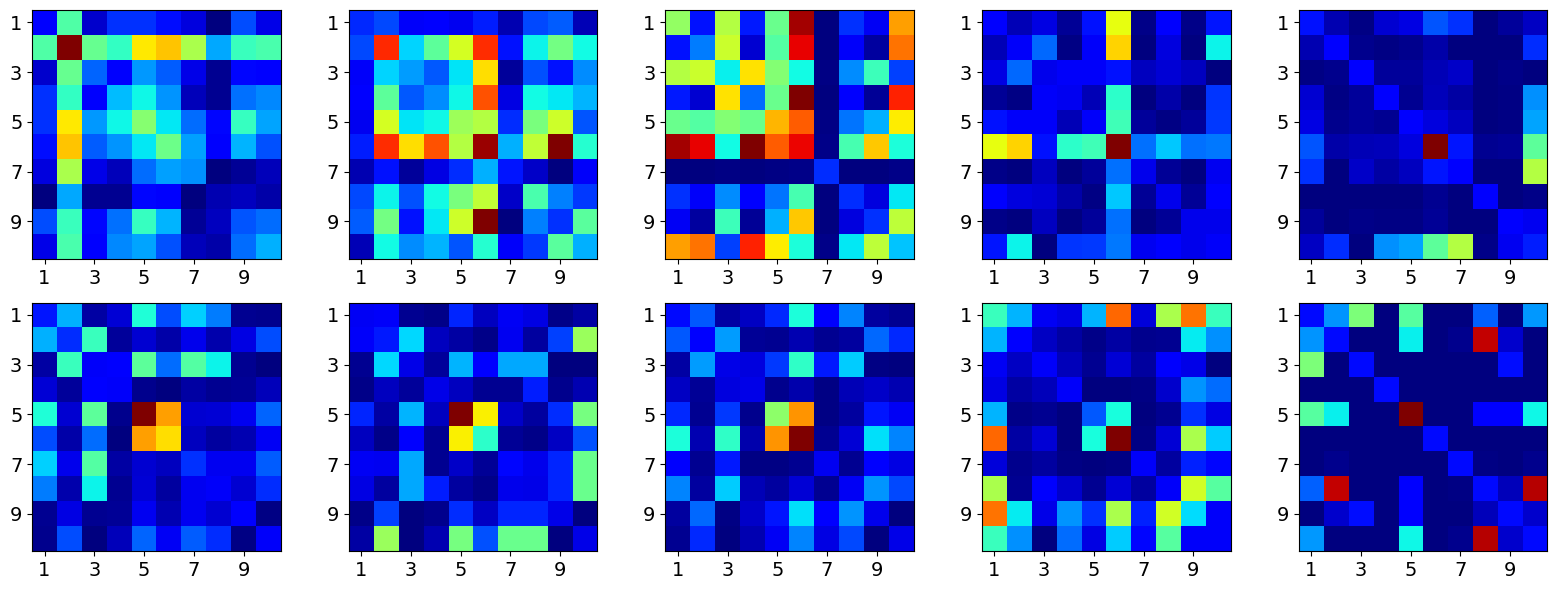

In [267]:
from matplotlib.ticker import MaxNLocator, FuncFormatter
%matplotlib inline
fig, axs = plt.subplots(2,5, figsize = (16,6))
for i, ax in enumerate(axs.flatten()):
    im = ax.imshow(gs_prgds.ProbAve[i] + torch.eye(10)*0.1, cmap = 'jet')
    ax.tick_params(axis='both', labelsize=14)
    # 确保刻度标签是整数，并限制显示的刻度数量
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    # 使用 FuncFormatter 来设置新的刻度标签，从1开始计数
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x) + 1))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: int(y) + 1))

plt.tight_layout()
plt.show()  

In [268]:
torch.save(gs_prgds.ProbAve, './qualitative_analysis/probave.pt')

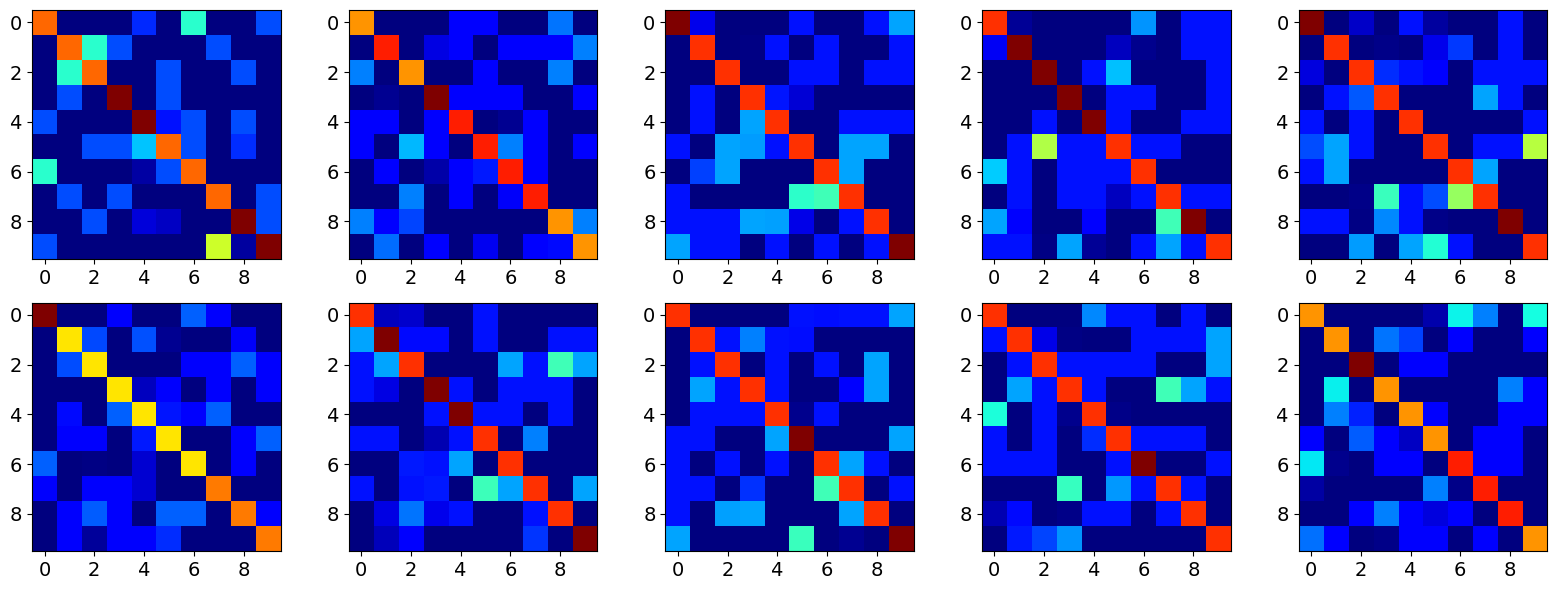

In [212]:
%matplotlib inline
fig, axs = plt.subplots(2,5, figsize = (16,6))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        probave = torch.mean(gs_prgds.pi[2:6], axis = 0)
    else:
        probave = torch.mean(gs_prgds.pi[i*6:i*6+6], axis = 0)
    im = ax.imshow(probave + torch.eye(10)*1, cmap = 'jet')
    ax.tick_params(axis='both', labelsize=14)
    # 确保刻度标签是整数，并限制显示的刻度数量
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
plt.tight_layout()
plt.show()

In [196]:
torch.save(gs_prgds.pi, './qualitative_analysis/pi.pt')

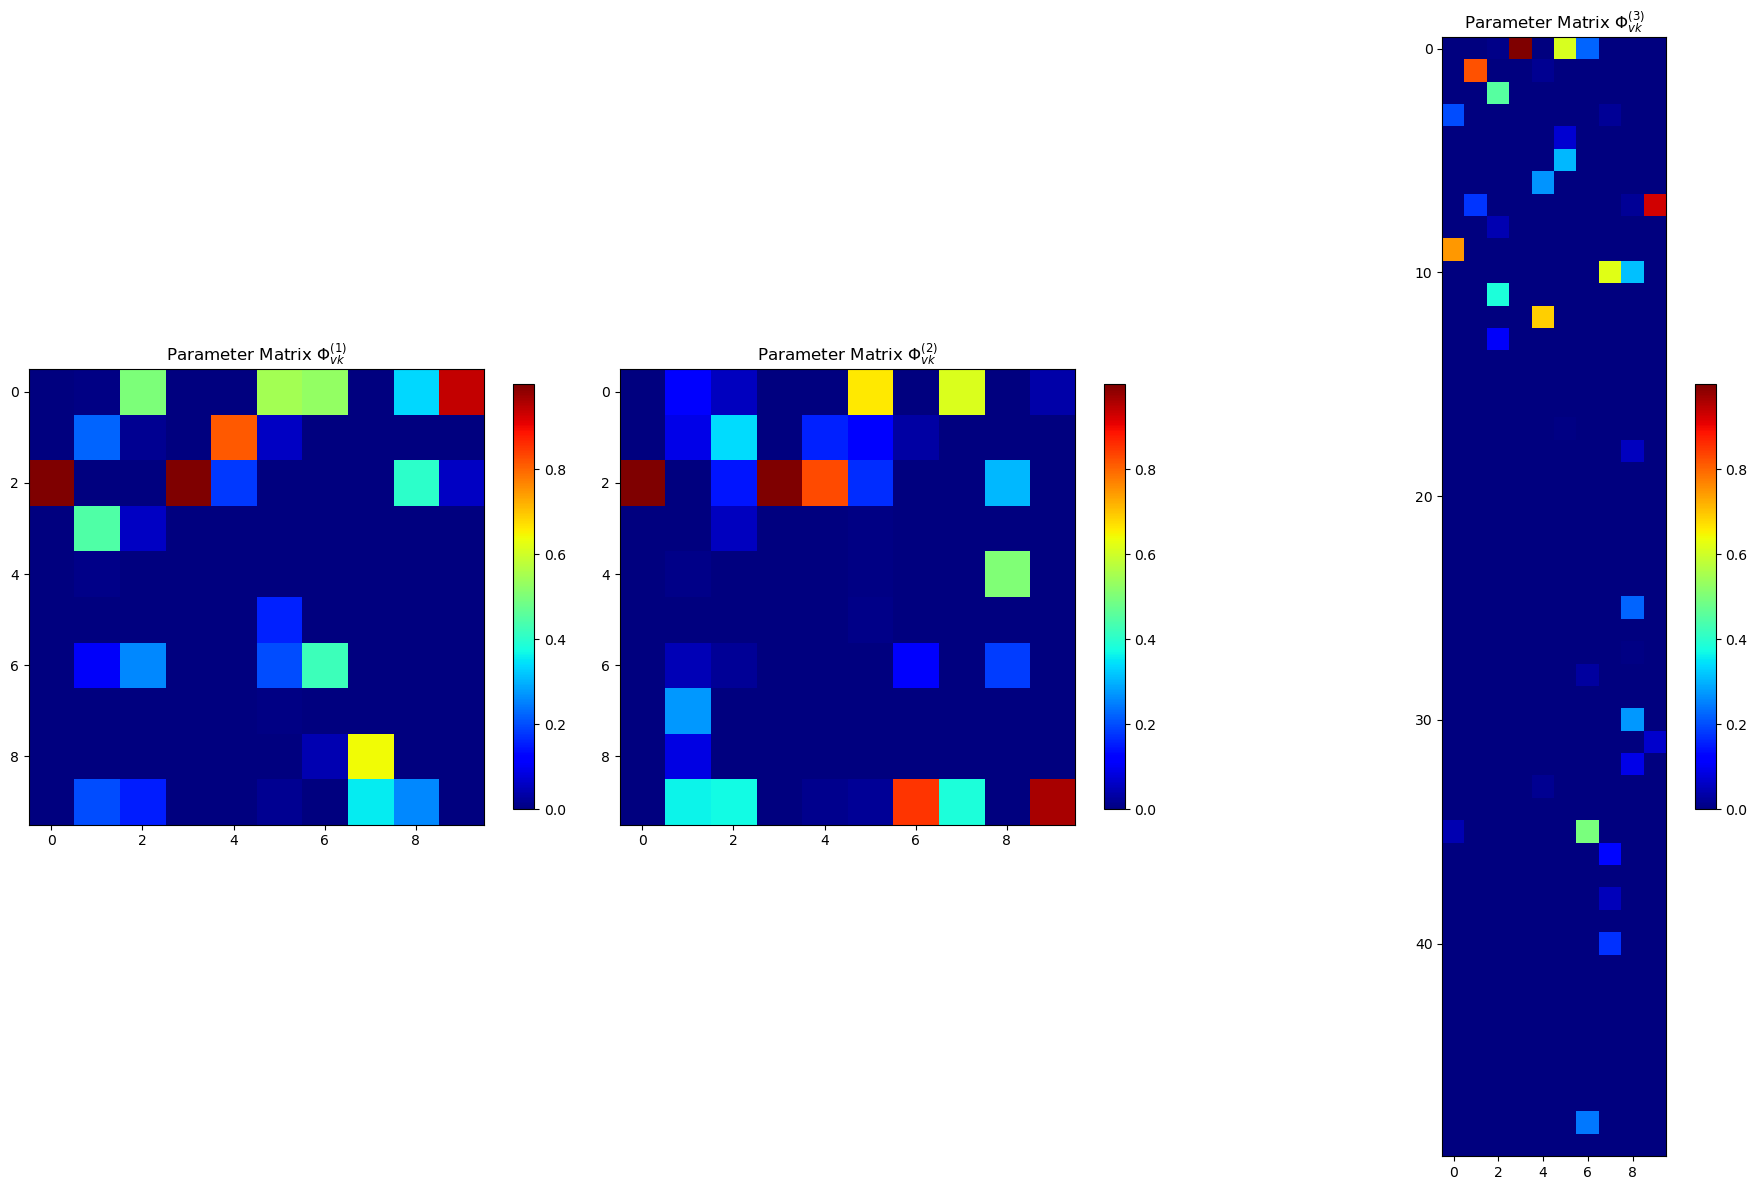

In [32]:
%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (18, 12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        im = ax.imshow(gs_prgds.phi[0], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(1)}$')
        cbar = plt.colorbar(im, ax = ax, shrink = 0.38)
    elif i == 1:
        im = ax.imshow(gs_prgds.phi[1], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(2)}$')
        cbar = plt.colorbar(im ,ax = ax, shrink = 0.38)
    elif i == 2:
        im = ax.imshow(gs_prgds.phi[2], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(3)}$')
        char = plt.colorbar(im, ax = ax, shrink = 0.38)
plt.tight_layout()
plt.show()

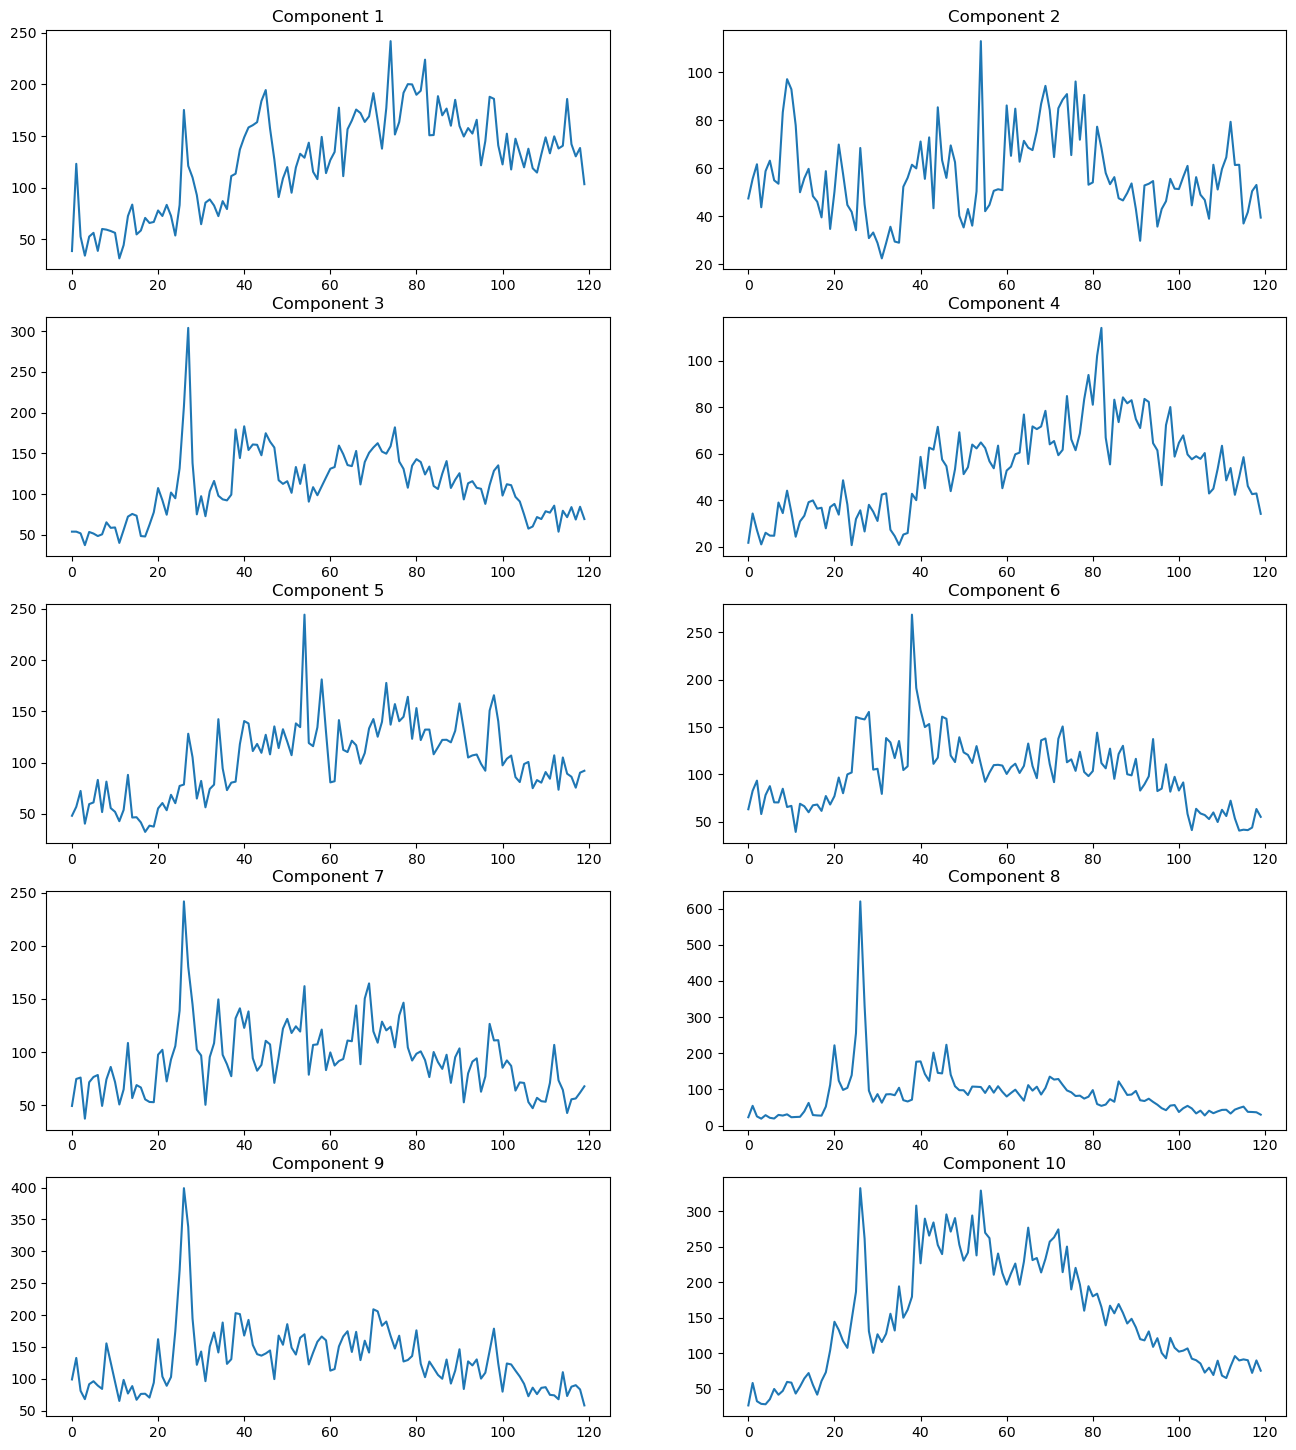

In [249]:
%matplotlib inline
fig, axs = plt.subplots(5, 2, figsize = (16,18))
for i, ax in enumerate(axs.flatten()):
    ax.plot(gs_prgds.the.T[i])
    ax.set_title('Component {}'.format(i+1))
plt.show()

In [63]:
torch.save(gs_prgds.the, './qualitative_analysis/theta.pt')
torch.save(gs_prgds.phi[0], './qualitative_analysis/phi1_source.pt')
torch.save(gs_prgds.phi[1], './qualitative_analysis/phi2_target.pt')
torch.save(gs_prgds.phi[2], './qualitative_analysis/phi3_action.pt')

In [43]:
qualitative_data['source']

array(['United States', 'United Kingdom', 'Australia', 'Poland', 'Spain',
       'Italy', 'South Korea', 'Syria', 'Libya', 'Iraq'], dtype='<U14')

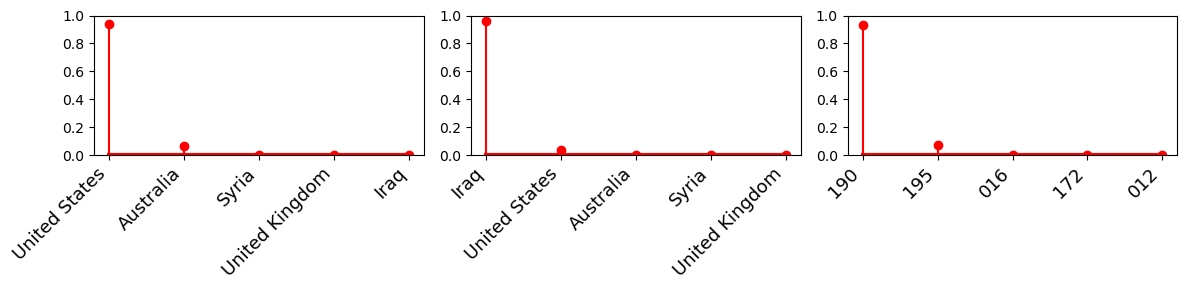

In [61]:
fig, axs = plt.subplots(1,3, figsize = (12,3))

source_country = qualitative_data['source']
target_country = qualitative_data['target']
action_type = qualitative_data['action']

source_phi = gs_prgds.phi[0][:,-1]
target_phi = gs_prgds.phi[1][:,-1]
action_phi = gs_prgds.phi[2][:,-1]

index_sortphi1 = np.argsort(source_phi)
index_sortphi1 = torch.flip(index_sortphi1, dims = [0])
index_sortphi2 = np.argsort(target_phi)
index_sortphi2 = torch.flip(index_sortphi2, dims = [0])
index_sortphi3 = np.argsort(action_phi)
index_sortphi3 = torch.flip(index_sortphi3, dims = [0])

x = 0.5 + np.arange(5)
source_y = np.zeros(5)
target_y = np.zeros(5)
action_y = np.zeros(5)
source_xlabel = []
target_xlabel = []
action_xlabel = []
for i in range(5):
    ind_p1 = index_sortphi1[i]
    ind_p2 = index_sortphi2[i]
    ind_p3 = index_sortphi3[i]
    source_y[i] = source_phi[ind_p1]
    target_y[i] = target_phi[ind_p2]
    action_y[i] = action_phi[ind_p3]
    source_xlabel.append(source_country[ind_p1])
    target_xlabel.append(target_country[ind_p2])
    action_xlabel.append(action_type[ind_p3])

y = [source_y, target_y, action_y]
xlabel = [source_xlabel, target_xlabel, action_xlabel]
for i, ax in enumerate(axs.flatten()):
    _,_, baseline = ax.stem(x, y[i], linefmt='red', markerfmt='ro', basefmt='r-')
    ax.set(ylim = (0,1))
    ax.set_xticks(x)
    ax.set_xticklabels(xlabel[i], rotation = 45, ha='right', fontsize = 13)
    plt.setp(baseline, linewidth = 3)

plt.tight_layout()
plt.show()

load data and plot

In [134]:
theta = torch.load('./qualitative_analysis/theta.pt')
phi1_source = torch.load('./qualitative_analysis/phi1_source.pt')
phi2_target = torch.load('./qualitative_analysis/phi2_target.pt')
phi3_action = torch.load('./qualitative_analysis/phi3_action.pt')

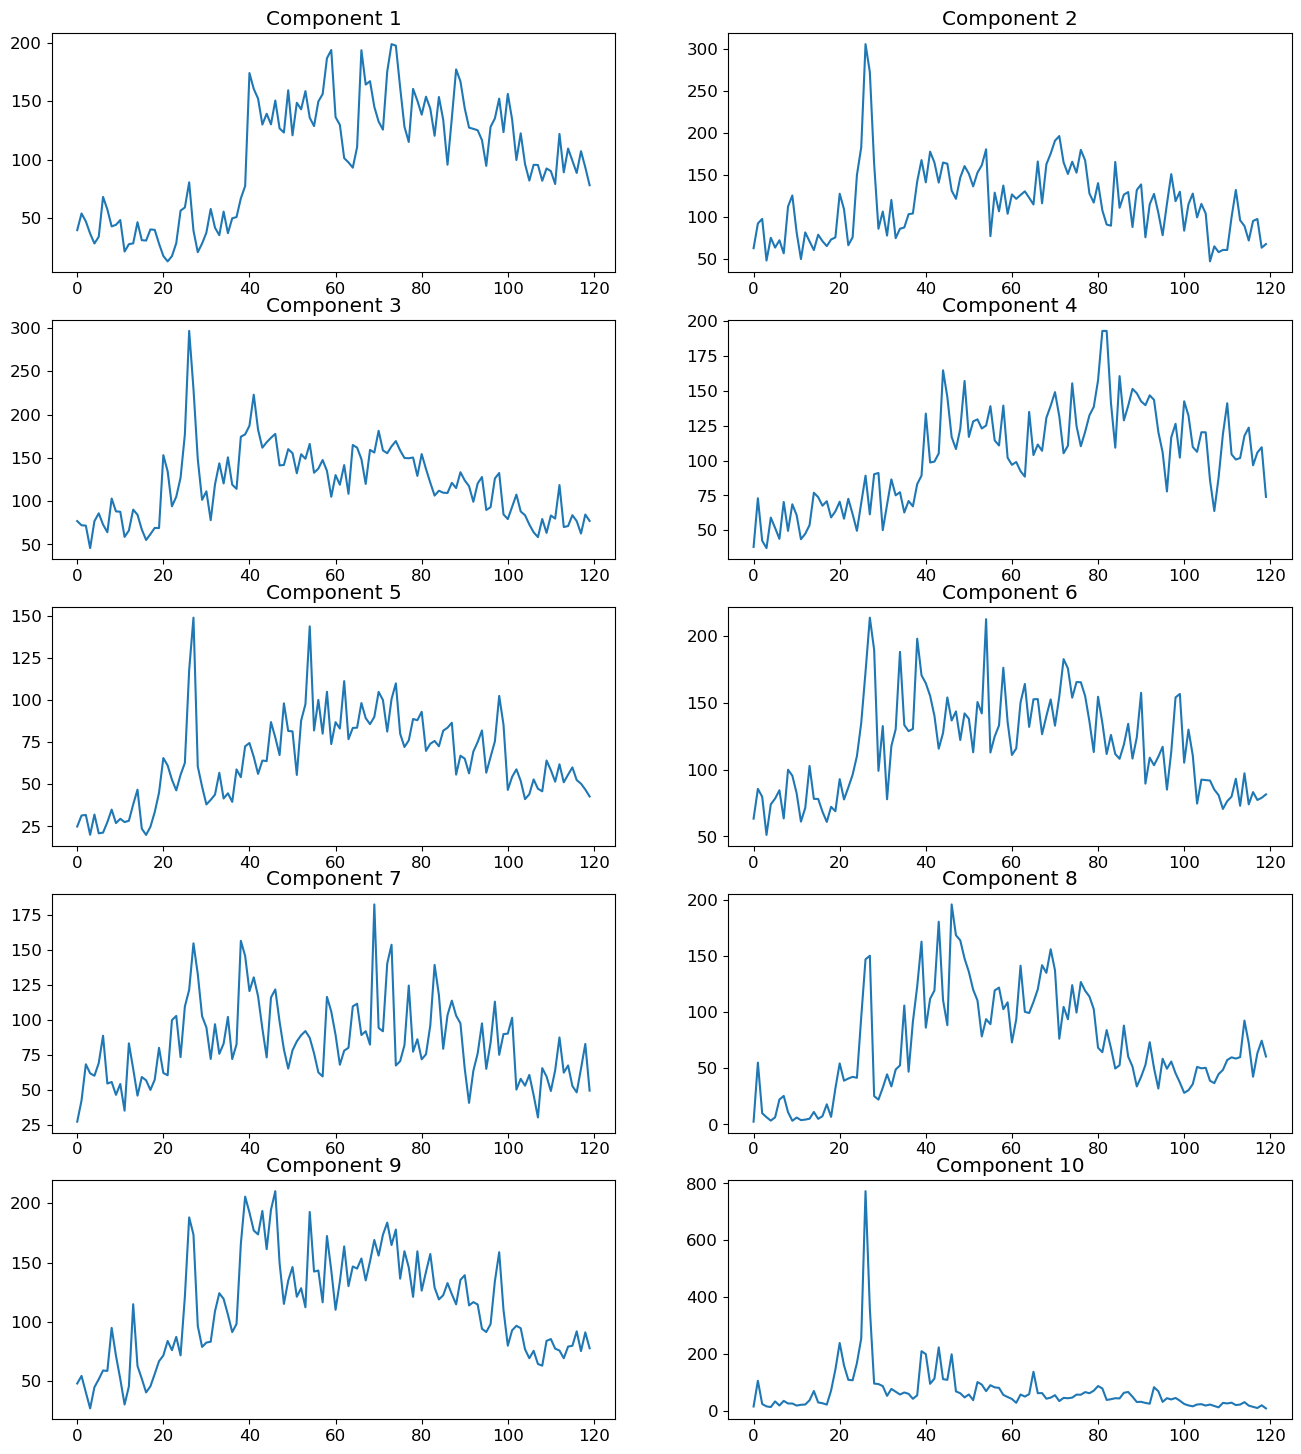

In [137]:
%matplotlib inline
plt.rcParams.update({'font.size': 12})
fig, axs = plt.subplots(5, 2, figsize = (16,18))
for i, ax in enumerate(axs.flatten()):
    ax.plot(theta.T[i])
    ax.set_title('Component {}'.format(i+1))
plt.show()

In [257]:
import matplotlib.ticker as ticker
def plot_main_dimensions_for_each_component(origin_data, phi, k, figsize = (12,3), fontsize = 13, color = 'red'):
    fig, axs = plt.subplots(1,3, figsize = figsize)

    source_country = origin_data['source']
    source_country[source_country == 'United States'] = 'USA'
    source_country[source_country == 'United Kingdom'] = 'UK'
    target_country = origin_data['target']
    target_country[target_country == 'United States'] = 'USA'
    target_country[target_country == 'United Kingdom'] = 'UK'
    action_type = origin_data['action']

    source_phi = phi[0][:,k]
    target_phi = phi[1][:,k]
    action_phi = phi[2][:,k]

    index_sortphi1 = np.argsort(source_phi)
    index_sortphi1 = torch.flip(index_sortphi1, dims = [0])
    index_sortphi2 = np.argsort(target_phi)
    index_sortphi2 = torch.flip(index_sortphi2, dims = [0])
    index_sortphi3 = np.argsort(action_phi)
    index_sortphi3 = torch.flip(index_sortphi3, dims = [0])

    x = 0.5 + np.arange(5)
    source_y = np.zeros(5)
    target_y = np.zeros(5)
    action_y = np.zeros(5)
    source_xlabel = []
    target_xlabel = []
    action_xlabel = []
    for i in range(5):
        ind_p1 = index_sortphi1[i]
        ind_p2 = index_sortphi2[i]
        ind_p3 = index_sortphi3[i]
        source_y[i] = source_phi[ind_p1]
        target_y[i] = target_phi[ind_p2]
        action_y[i] = action_phi[ind_p3]
        source_xlabel.append(source_country[ind_p1])
        target_xlabel.append(target_country[ind_p2])
        action_xlabel.append(action_type[ind_p3])

    y = [source_y, target_y, action_y]
    xlabel = [source_xlabel, target_xlabel, action_xlabel]
    for i, ax in enumerate(axs.flatten()):
        markerline, stemline, baseline = ax.stem(x, y[i])
        ax.set_xticks(x)
        ax.set_xticklabels(xlabel[i], rotation = 45, ha='right', fontsize = fontsize)
        ax.tick_params(axis='y', labelsize=fontsize)
        # 设置纵轴刻度为5个
        num_yticks = 3
        ax.set_yticks(np.linspace(0, 1, num_yticks))
        ax.set(ylim = (-0.07, 1))
        # 设置纵轴刻度为保留一位小数
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

        if i == 0:
            color = (169/255, 16/255, 22/255)
        elif i == 1:
            color = (4/255, 112/255, 47/255)
        elif i == 2:
            color = (86/255, 44/255, 145/255)

        plt.setp(baseline, linewidth = 1.5, color = color)
        plt.setp(stemline, 'linewidth', 1.5, color = color)
        plt.setp(markerline, 'markersize', 5, color = color)




    plt.tight_layout()
    plt.show()

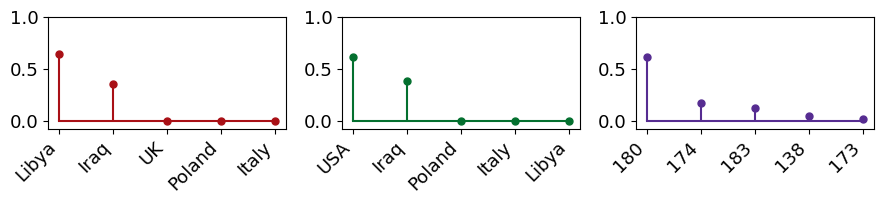

In [266]:
%matplotlib inline
plot_main_dimensions_for_each_component(qualitative_data, [phi1_source,phi2_target,phi3_action], k=7, figsize = (9,2.2), fontsize = 13, color = (11/255, 85/255, 159/255))

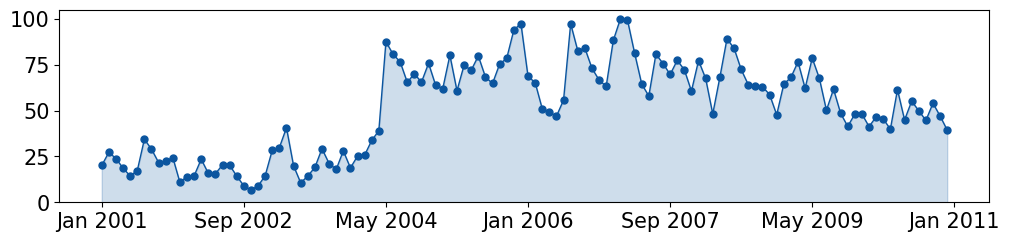

In [236]:
k = 0
normalized_theta = theta.T[k]* (100/torch.max(theta.T[k]))
plt.figure(figsize = (12,2.5))
plt.plot(normalized_theta, 'o-', markersize = 5, linewidth = 1, color = (11/255, 85/255, 159/255))

# 填充折线图下方的区域
plt.fill_between(range(0, 120), normalized_theta, color=(11/255, 85/255, 159/255), alpha=0.2)

# 自定义的横轴标签和对应的位置
x_labels = ['Jan 2001', 'Sep 2002', 'May 2004', 'Jan 2006', 'Sep 2007', 'May 2009', 'Jan 2011']
x_positions = [0, 20, 40, 60, 80, 100, 120]

plt.xticks(x_positions, x_labels, fontsize=15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
# 设置 y 轴范围，使 0 刻度在坐标轴原点位置
plt.ylim(bottom=0)
# 移除横纵轴上的刻度短线
#plt.tick_params(axis='both', which='both', length=0)
# 添加虚线
#x_location = 26  # 指定的 x 位置
#plt.axvline(x=x_location, color=(169/255, 16/255, 22/255), linestyle='--', linewidth=1)
            
plt.show()

sample $\pi$ from ProbAve

In [77]:
probave = torch.load('./qualitative_analysis/probave.pt')

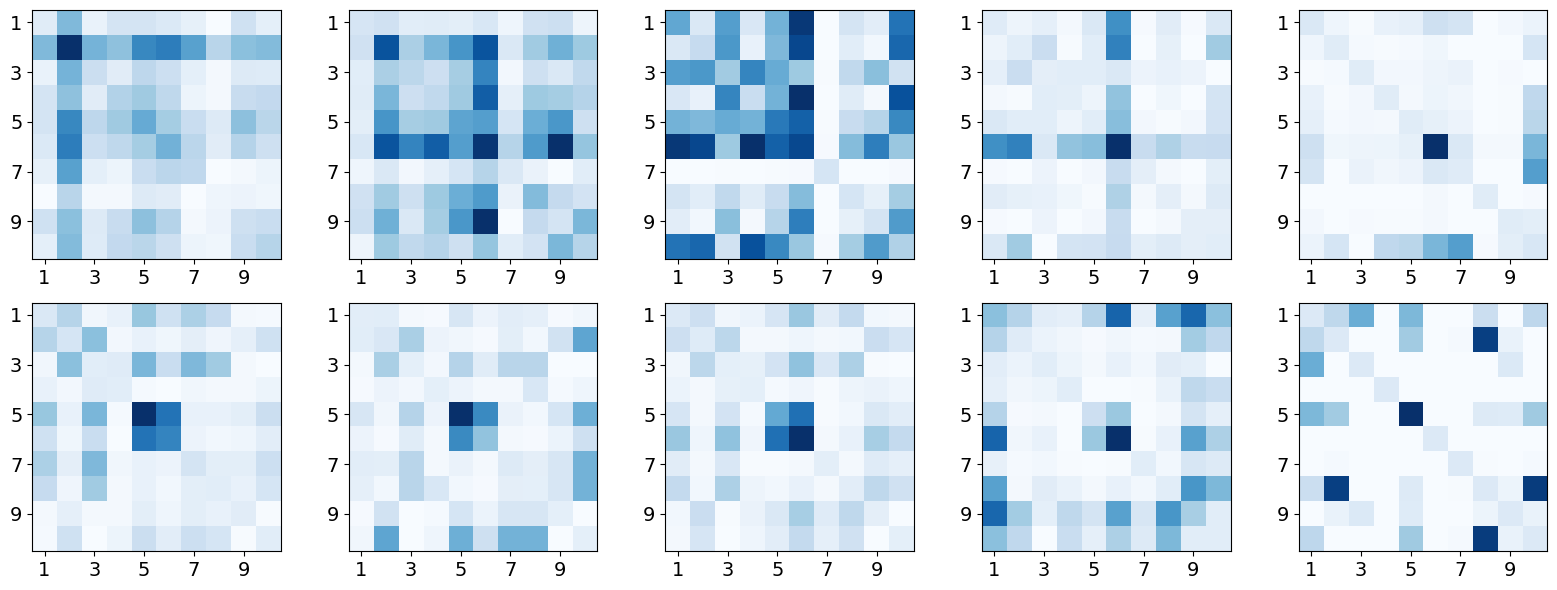

In [104]:
from matplotlib.ticker import MaxNLocator, FuncFormatter
%matplotlib inline

fig, axs = plt.subplots(2,5, figsize = (16,6))
for i, ax in enumerate(axs.flatten()):
    im = ax.imshow(probave[i] + torch.eye(10)*0.1, cmap = 'Blues')
    ax.tick_params(axis='both', labelsize=14)
    # 确保刻度标签是整数，并限制显示的刻度数量
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    # 使用 FuncFormatter 来设置新的刻度标签，从1开始计数
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x) + 1))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: int(y) + 1))

plt.tight_layout()
plt.show()  

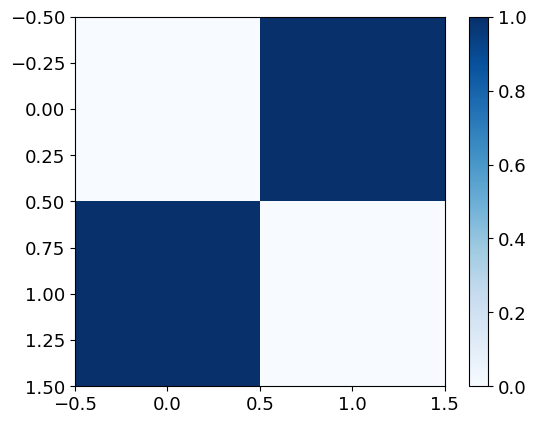

In [126]:
# 设置全局字体大小
plt.rcParams.update({'font.size': 13})
plt.imshow([[0,1],[1,0]], cmap = 'Blues')
plt.colorbar()
plt.show()

In [50]:
from torch. distributions import Dirichlet
pi_collection = []
pi = torch.zeros(size = (10,10,10))
eps = 1e-38
for i in range(10):
    for j in range(10):
        pi[i][:,j] = Dirichlet((probave[i][:,j]+1e-38)/torch.linalg.norm(probave[i][:,j] + 1e-38)).sample()


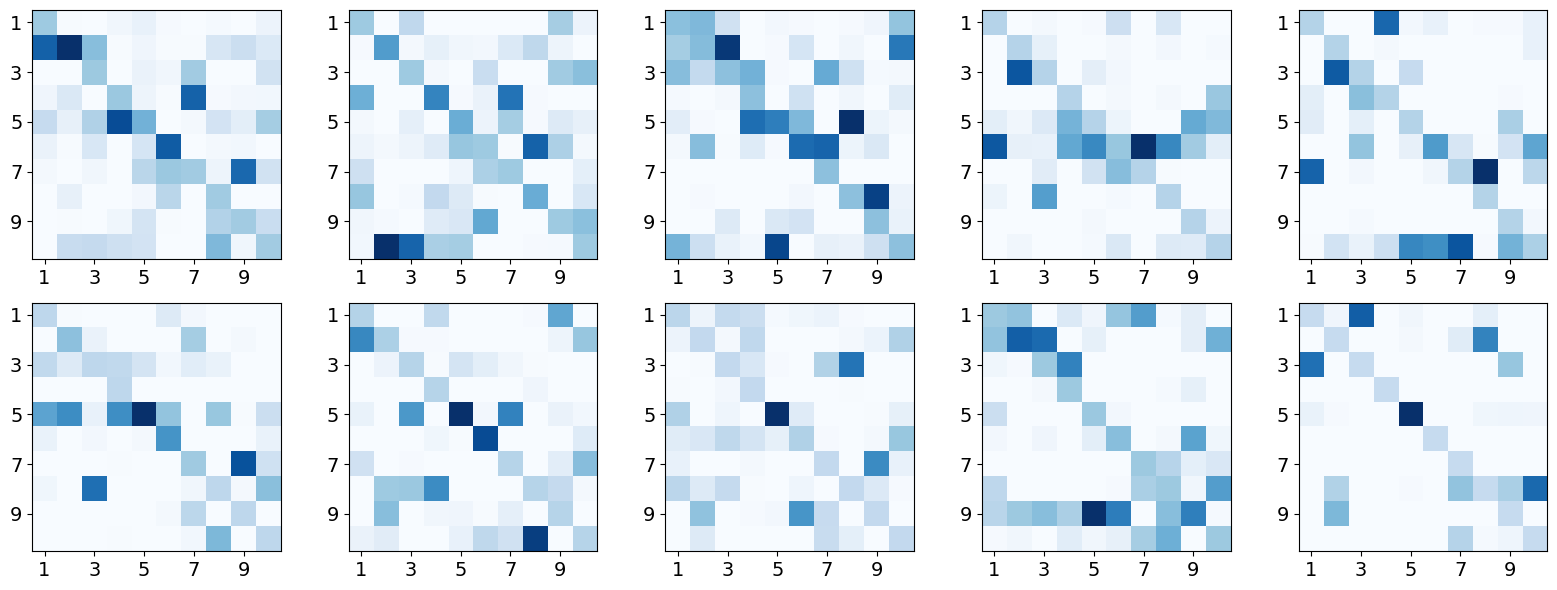

In [100]:
from matplotlib.ticker import MaxNLocator, FuncFormatter
%matplotlib inline
fig, axs = plt.subplots(2,5, figsize = (16,6))
for i, ax in enumerate(axs.flatten()):
    im = ax.imshow(pi[i] + torch.eye(10)*0.3, cmap = 'Blues')
    ax.tick_params(axis='both', labelsize=14)
    # 确保刻度标签是整数，并限制显示的刻度数量
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    # 使用 FuncFormatter 来设置新的刻度标签，从1开始计数
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x) + 1))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: int(y) + 1))
plt.tight_layout()
plt.show()

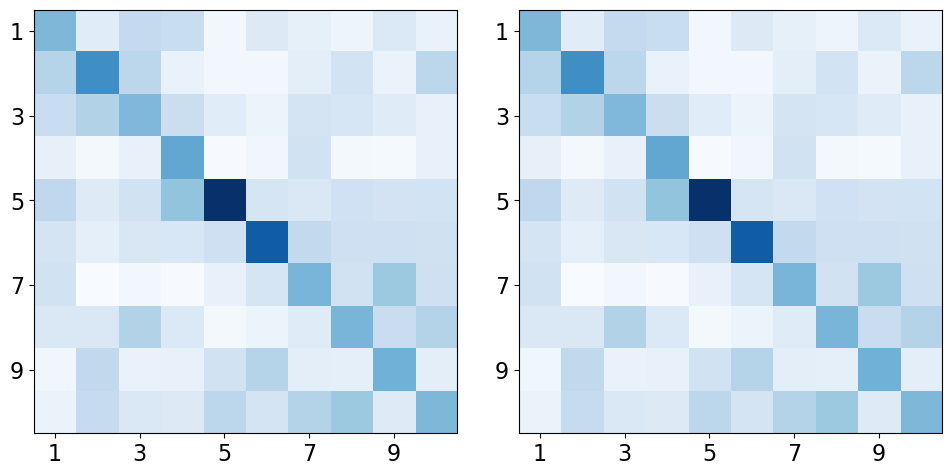

In [133]:
from matplotlib.ticker import MaxNLocator, FuncFormatter
%matplotlib inline
pi_mean = torch.mean(pi, axis = 0) + torch.eye(10)*0.3
for i in range(10):
    pi_mean[:,i] = pi_mean[:,i] / torch.sum(pi_mean[:,i])
fig, axs = plt.subplots(1,2, figsize = (10,5))
for i, ax in enumerate(axs):
    im = ax.imshow(pi_mean, cmap = 'Blues')
    ax.tick_params(axis='both', labelsize=16)
    # 确保刻度标签是整数，并限制显示的刻度数量
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    # 使用 FuncFormatter 来设置新的刻度标签，从1开始计数
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x) + 1))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: int(y) + 1))
plt.tight_layout()
plt.show()